#Implementacion de Regresion Logistica

##La regresión logística es un algoritmo de aprendizaje supervisado de machine learning en ciencia de datos. Es un tipo de algoritmo de clasificación que predice un resultado discreto o categórico.                                                                  
####La complejidad temporal de entrenamiento del modelo es
##$$O(n \cdot d \cdot i)$$
####Donde n es el numero de muestras, d es el numero de dimensiones o caracteristicas de esta, e i es el numero de iteracciones.

####Codigo Adaptado de:
https://machinelearningmastery.com/implement-logistic-regression-stochastic-gradient-descent-scratch-python/?utm_source


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

from random import seed
from random import randrange

from math import exp

import time

In [25]:
url = 'https://raw.githubusercontent.com/angelemmavelasco/JAPI/refs/heads/main/data/sales.csv'
df = pd.read_csv(url)
df.head()

,id,doc_id,sale_date,total_cost,net_price,gross_price,profit,quantity,customer_id,product_id,product_class_id,route_id,warehouse_id
0,654255,mx 51841,2025-08-04,5681.140252,7500.0000,7500.0000,1818.859748,8,20889,NLAM40,nat,96.0,cdmx
1,654256,mx 51841,2025-08-04,353.420434,469.8276,469.8276,116.407166,2,20889,NLAM6,nat,96.0,cdmx
2,654257,mx 51841,2025-08-04,1240.348891,1646.5517,1646.5517,406.202809,2,20889,PREM40,dmd,96.0,cdmx
3,654258,mx 51841,2025-08-04,649.051367,862.0690,862.0690,213.017633,5,20889,PREM6,dmd,96.0,cdmx
4,654259,mx 51841,2025-08-04,424.642649,556.0345,556.0345,131.391851,2,20889,PSC5,tow,96.0,cdmx


##Implementacion manual de Regresion Logistica

In [26]:
df['sale_date'] = pd.to_datetime(
    df['sale_date']
)

reference_date = df['sale_date'].max()

rfm = df.groupby('customer_id').agg({

    'sale_date': lambda x:
        (reference_date - x.max()).days,

    'doc_id': 'nunique',

    'net_price': 'sum'

}).reset_index()

rfm.columns = [

    'customer_id',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm['target'] = (

    (rfm['Recency'] <= 100)

    &

    (rfm['Frequency'] >= 30)

    &

    (rfm['Monetary'] >= 100000)

).astype(int)

features = [
    'Recency',
    'Frequency',
    'Monetary'
]

dataset = rfm[
    features + ['target']
].values.tolist()


In [27]:
def dataset_minmax(dataset):

    minmax = list()

    for i in range(len(dataset[0])):

        col_values = [
            row[i]
            for row in dataset
        ]

        value_min = min(col_values)
        value_max = max(col_values)

        minmax.append([
            value_min,
            value_max
        ])

    return minmax

def normalize_dataset(
    dataset,
    minmax
):

    for row in dataset:

        for i in range(len(row)):

            denominator = (
                minmax[i][1]
                - minmax[i][0]
            )

            if denominator != 0:

                row[i] = (
                    row[i]
                    - minmax[i][0]
                ) / denominator

            else:

                row[i] = 0.0

def cross_validation_split(
    dataset,
    n_folds
):

    dataset_split = list()

    dataset_copy = list(dataset)

    fold_size = int(
        len(dataset) / n_folds
    )

    for i in range(n_folds):

        fold = list()

        while len(fold) < fold_size:

            index = randrange(
                len(dataset_copy)
            )

            fold.append(
                dataset_copy.pop(index)
            )

        dataset_split.append(
            fold
        )

    return dataset_split

def accuracy_metric(
    actual,
    predicted
):

    correct = 0

    for i in range(len(actual)):

        if actual[i] == predicted[i]:

            correct += 1

    return (
        correct / float(len(actual))
    ) * 100.0

def evaluate_algorithm(
    dataset,
    algorithm,
    n_folds,
    *args
):

    folds = cross_validation_split(
        dataset,
        n_folds
    )

    scores = list()

    for fold in folds:

        train_set = list(folds)

        train_set.remove(fold)

        train_set = sum(
            train_set,
            []
        )

        test_set = list()

        for row in fold:

            row_copy = list(row)

            test_set.append(
                row_copy
            )

            row_copy[-1] = None

        predicted = algorithm(
            train_set,
            test_set,
            *args
        )

        actual = [

            row[-1]
            for row in fold
        ]

        accuracy = accuracy_metric(
            actual,
            predicted
        )

        scores.append(
            accuracy
        )

    return scores

def predict(
    row,
    coefficients
):

    yhat = coefficients[0]

    for i in range(len(row)-1):

        yhat += (
            coefficients[i + 1]
            * row[i]
        )

    return 1.0 / (
        1.0 + exp(-yhat)
    )

def coefficients_sgd(
    train,
    l_rate,
    n_epoch
):

    coef = [

        0.0
        for i in range(len(train[0]))

    ]

    for epoch in range(n_epoch):

        for row in train:

            yhat = predict(
                row,
                coef
            )

            error = (
                row[-1] - yhat
            )

            # Bias
            coef[0] = (

                coef[0]

                + l_rate
                * error
                * yhat
                * (1.0 - yhat)

            )

            # Pesos
            for i in range(len(row)-1):

                coef[i + 1] = (

                    coef[i + 1]

                    + l_rate
                    * error
                    * yhat
                    * (1.0 - yhat)
                    * row[i]

                )

    return coef

def logistic_regression(
    train,
    test,
    l_rate,
    n_epoch
):

    predictions = list()

    coef = coefficients_sgd(
        train,
        l_rate,
        n_epoch
    )

    for row in test:

        yhat = predict(
            row,
            coef
        )

        yhat = round(yhat)

        predictions.append(
            yhat
        )

    return predictions

minmax = dataset_minmax(dataset)

normalize_dataset(
    dataset,
    minmax
)

In [28]:
seed(1)

n_folds = 5

l_rate = 0.1

n_epoch = 100

start = time.time()

scores = evaluate_algorithm(

    dataset,
    logistic_regression,
    n_folds,
    l_rate,
    n_epoch

)

end = time.time()


In [29]:
print(
    'Scores: %s'
    % scores
)

print(

    'Mean Accuracy: %.3f%%'
    % (
        sum(scores)
        / float(len(scores))
    )
)

Scores: [85.41062801932368, 85.89371980676329, 85.79710144927536, 85.21739130434783, 87.53623188405797]
Mean Accuracy: 85.971%


##Medicion de tiempo de ejecucion del algorito

In [30]:
print(
    f"Tiempo Logistic Regression manual: "
    f"{end - start:.6f} segundos"
)

Tiempo Logistic Regression manual: 3.270414 segundos


##Medicion de tiempo asintotico del algoritmo

###Codigo adaptado de:

https://pypi.org/project/perfplot/0.8.2/?utm_source=


Tamaño: 100 | Tiempo: 0.072824 segundos
Tamaño: 300 | Tiempo: 0.196972 segundos
Tamaño: 500 | Tiempo: 0.331359 segundos
Tamaño: 1000 | Tiempo: 0.375196 segundos
Tamaño: 2000 | Tiempo: 0.743847 segundos
Tamaño: 4000 | Tiempo: 1.586582 segundos


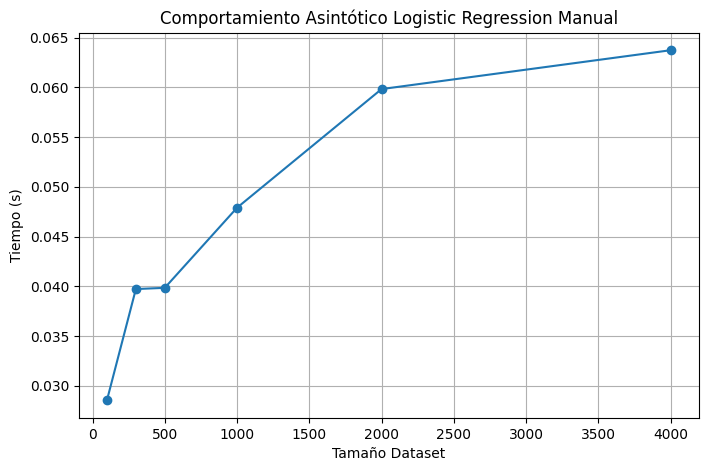

In [31]:
sizes = [
    100,
    300,
    500,
    1000,
    2000,
    4000
]

lr_manual_times = []

for size in sizes:

    subset = dataset[:size]

    start = time.time()

    scores = evaluate_algorithm(

        subset,
        logistic_regression,
        n_folds,
        l_rate,
        n_epoch

    )

    end = time.time()

    execution_time = (
        end - start
    )

    lr_manual_times.append(
    execution_time
    )

    print(

        f"Tamaño: {size} | "
        f"Tiempo: "
        f"{execution_time:.6f} segundos"

    )

plt.figure(figsize=(8,5))

plt.plot(

    sizes,
    times,
    marker='o'

)

plt.xlabel(
    "Tamaño Dataset"
)

plt.ylabel(
    "Tiempo (s)"
)

plt.title(
    "Comportamiento Asintótico Logistic Regression Manual"
)

plt.grid(True)

plt.show()

##Implementacion de Regresion Logistica de Sklearn

https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

###¿Como optimiza sklearn su modelo?

Regresión logística (scikit-learn)

Optimiza los coeficientes resolviendo un problema de minimización de una función de pérdida convexa (log-loss).
Lo hace mediante métodos numéricos iterativos llamados solvers:

lbfgs: método quasi-Newton, usa aproximación de la segunda derivada.
liblinear: optimización por descenso coordenado.
sag / saga: variantes de gradiente estocástico, eficientes en grandes datasets.

En todos los casos, el objetivo es ajustar los pesos para minimizar el error de clasificación.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [33]:
X = rfm[[
    'Recency',
    'Frequency',
    'Monetary'
]]

y = rfm['target']

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


model = LogisticRegression(
    max_iter=1000
)

start = time.time()

scores = cross_val_score(

    model,

    X_scaled,

    y,

    cv=5,

    scoring='accuracy'

)

end = time.time()

print(
    "Scores:",
    scores
)

print(

    "Mean Accuracy: %.3f%%"
    % (scores.mean() * 100)

)

Scores: [0.81467181 0.81563707 0.81853282 0.81756757 0.81256039]
Mean Accuracy: 81.579%


##Medicion de tiempo de entrenamiento

In [34]:
print(
    f"Tiempo Logistic Regression sklearn: "
    f"{end - start:.6f} segundos"
)

Tiempo Logistic Regression sklearn: 0.068608 segundos


##Medicion de tiempo asintotico Sklearn

Tamaño: 100 | Tiempo entrenamiento sklearn: 0.004147 segundos
Tamaño: 300 | Tiempo entrenamiento sklearn: 0.009573 segundos
Tamaño: 500 | Tiempo entrenamiento sklearn: 0.003862 segundos
Tamaño: 1000 | Tiempo entrenamiento sklearn: 0.004497 segundos
Tamaño: 2000 | Tiempo entrenamiento sklearn: 0.006199 segundos
Tamaño: 4000 | Tiempo entrenamiento sklearn: 0.008405 segundos


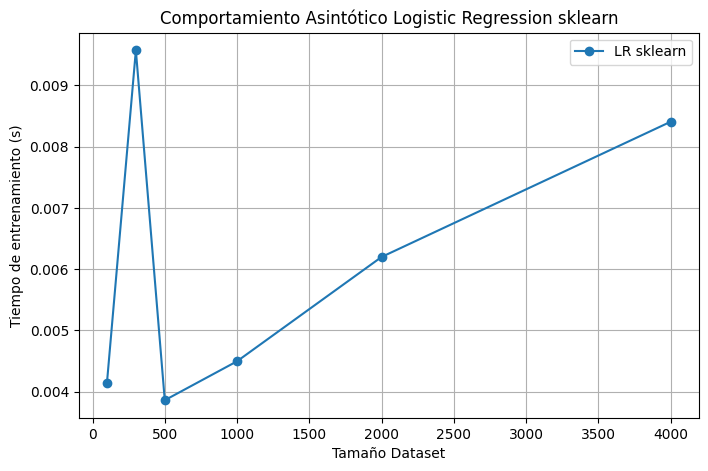

In [37]:
sizes = [
    100,
    300,
    500,
    1000,
    2000,
    4000
]

lr_sklearn_times = []

for size in sizes:

    X_subset = X_scaled[:size]
    y_subset = y[:size]

    model = LogisticRegression(
        max_iter=1000
    )

    start = time.time()

    model.fit(
        X_subset,
        y_subset
    )

    end = time.time()

    execution_time = end - start

    lr_sklearn_times.append(
        execution_time
    )

    print(
        f"Tamaño: {size} | "
        f"Tiempo entrenamiento sklearn: "
        f"{execution_time:.6f} segundos"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    lr_sklearn_times,
    marker='o',
    label='LR sklearn'
)

plt.xlabel("Tamaño Dataset")
plt.ylabel("Tiempo de entrenamiento (s)")
plt.title("Comportamiento Asintótico Logistic Regression sklearn")
plt.legend()
plt.grid(True)
plt.show()

###La complejidad de la regresión logística mediante descenso de gradiente estocástico (SGD) es:

###$$
O(e \cdot n \cdot d)
$$

donde:
- e = número de epochs/iteraciones
- n = número de muestras
- d = número de características

En este experimento, e y d permanecen constantes, por lo que el crecimiento empírico observado se aproxima a O(n).

##Comparacion

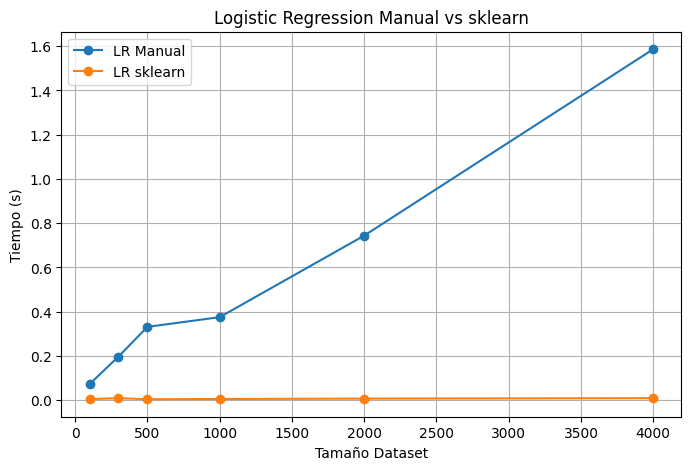

In [36]:
plt.figure(figsize=(8,5))

plt.plot(

    sizes,
    lr_manual_times,

    marker='o',

    label='LR Manual'

)

plt.plot(

    sizes,
    lr_sklearn_times,

    marker='o',

    label='LR sklearn'

)

plt.xlabel(
    "Tamaño Dataset"
)

plt.ylabel(
    "Tiempo (s)"
)

plt.title(
    "Logistic Regression Manual vs sklearn"
)

plt.legend()

plt.grid(True)

plt.show()

###Se observa que sklearn presenta menores tiempos de ejecución debido al uso de solvers optimizados y rutinas compiladas, mientras que la implementación manual utiliza ciclos explícitos en Python y una implementación básica de SGD.

Referencias:

https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html